In [627]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [628]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [629]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [630]:
df.shape

(7043, 33)

In [631]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [632]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


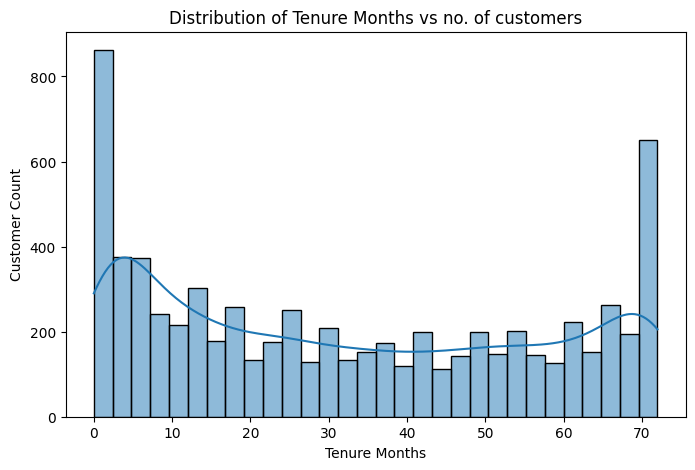

In [633]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months vs no. of customers')
plt.show()


In [634]:
df['Tenure Months'].max()
# df['Tenure Months'].min() -> 0
# 72/30=2.4 smth -> bin width

72

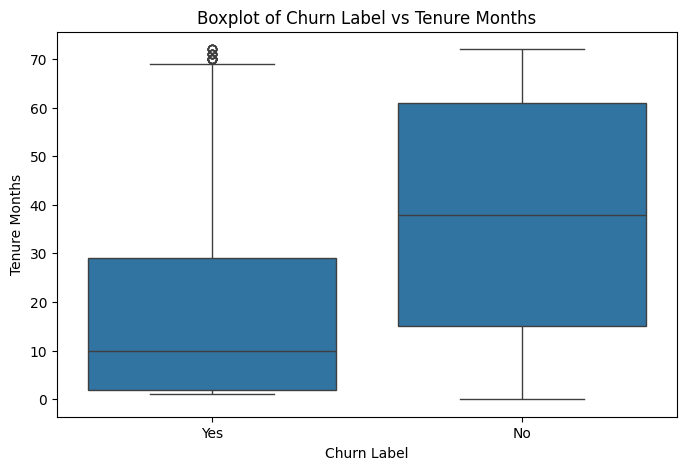

In [635]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)  #univariate visualization
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Boxplot of Churn Label vs Tenure Months')
plt.show()

In [636]:
df['Churn Label'].unique() #find categories of a col

array(['Yes', 'No'], dtype=object)

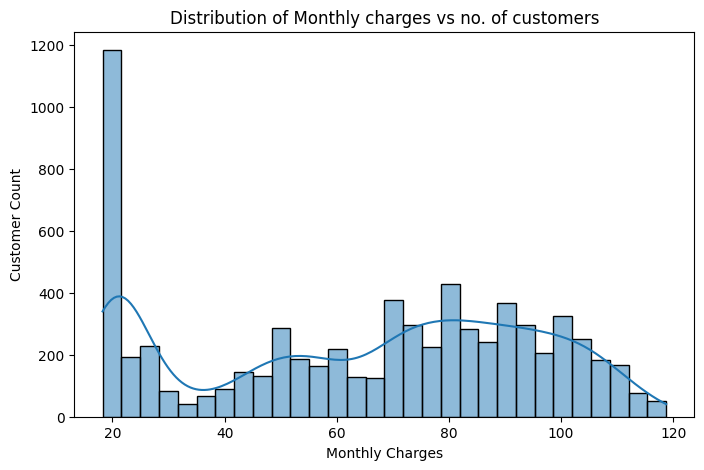

In [637]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of Monthly charges vs no. of customers')
plt.show()

In [638]:
df['Monthly Charges'].max()
df['Monthly Charges'].min()

18.25

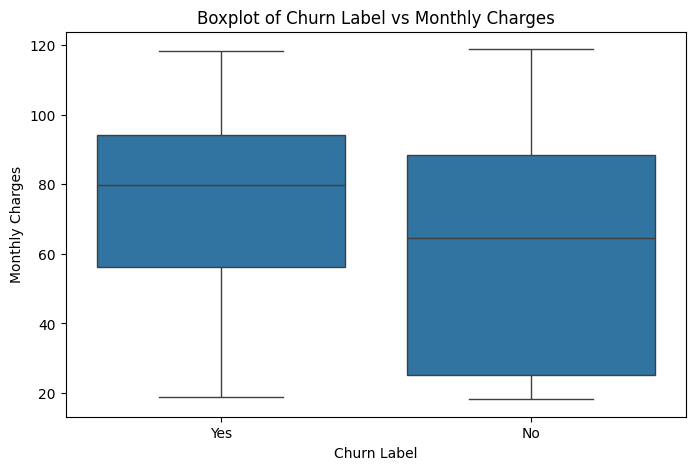

In [639]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Boxplot of Churn Label vs Monthly Charges')
plt.show()

In [640]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25, 0.5, 0.75])  #show rows where churn label is yes

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [641]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [642]:
df['Monthly Charges'].quantile([0.25, 0.5, 0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [643]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

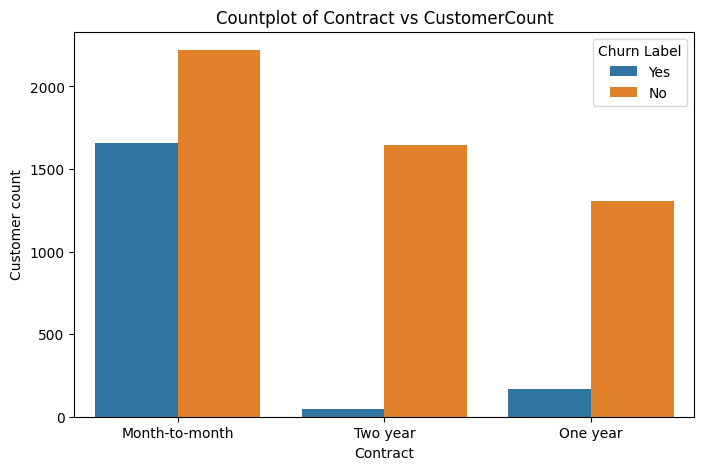

In [644]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)  #categorical data distribution
plt.xlabel('Contract')
plt.ylabel('Customer count')
plt.title('Countplot of Contract vs CustomerCount')
plt.show()

In [645]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

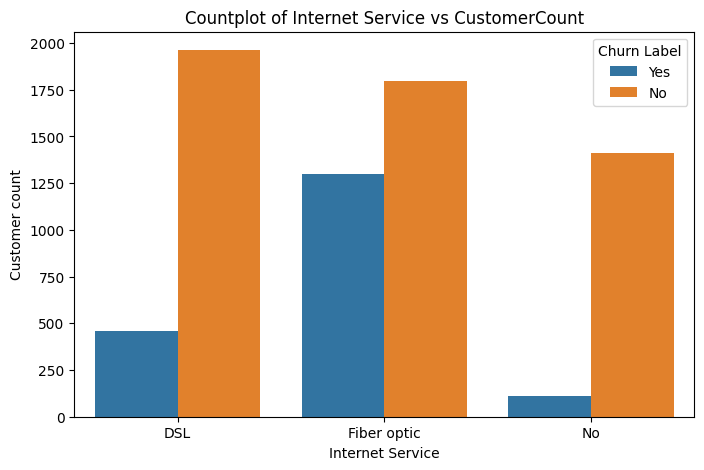

In [646]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('Customer count')
plt.title('Countplot of Internet Service vs CustomerCount')
plt.show()

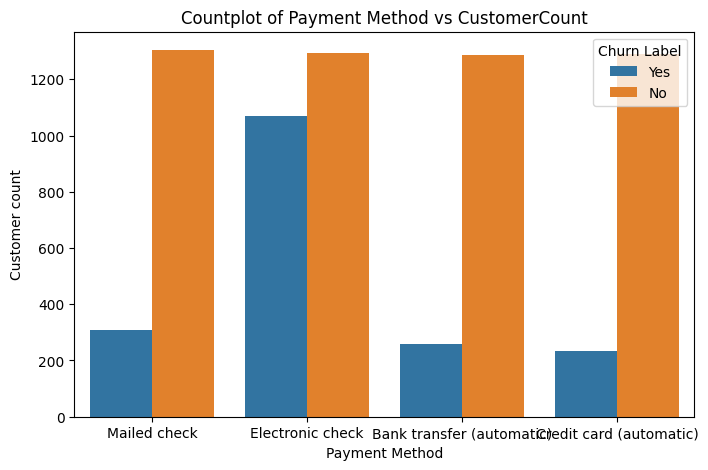

In [647]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('Customer count')
plt.title('Countplot of Payment Method vs CustomerCount')
plt.show()

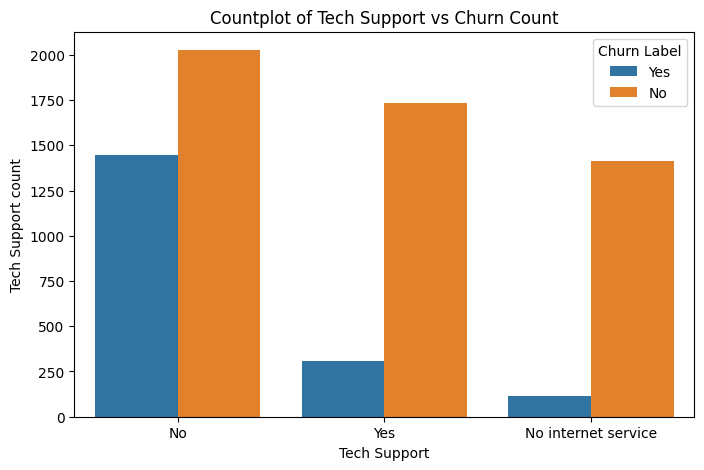

In [648]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('Tech Support count')
plt.title('Countplot of Tech Support vs Churn Count')
plt.show()

In [649]:
avg_tenure=df.groupby('Churn Label').agg({'Tenure Months': 'mean'})
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [650]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure  #or we use this, different syntax same thing

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [651]:
numerical_cols=['Tenure Months','Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix=df[numerical_cols].corr()
correlation_matrix
#months inc, churn chances less
#charges inc, churn chances inc
#churn score n value similar, so both inc (0.66)
#CLTV inc when churn chances dec

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [652]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')  # normalize each row
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [653]:
# Data cleaning
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')

In [654]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [655]:
df['Total Charges'].isnull().sum()


np.int64(11)

In [656]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [657]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [658]:
df.shape

(7043, 33)

Churn value is output column

In [659]:
drop_columns=['CustomerID','Count','Country', 'State', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']

In [660]:
df=df.drop(columns=drop_columns)  # cause data leak or are irrelevant

In [661]:
df.shape

(7043, 21)

In [662]:
df_encoded=pd.get_dummies(df, drop_first=True)

In [663]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [664]:
#we drop cities as well, since there's so many cities - 1000s
#so always check encoding n shape on different data not your data

In [665]:
df=df.drop(columns=['City'])

In [666]:
df_encoded.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura Hills',
       'City_Aguanga', 'City_Ahwahnee',
       ...
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object', length=1159)

In [667]:
df.shape

(7043, 20)

In [668]:
df_encoded=pd.get_dummies(df, drop_first=True)
#leftover data now encoded

In [669]:
df_encoded.shape

(7043, 31)

In [670]:
# X=df_encoded.drop(columns=['Churn Value'])
# y=df_encoded['Churn Value']
#in drop you need to specify column or row, axis 0 (row) or axis 1 (col)

In [671]:
X=df_encoded.drop('Churn Value', axis=1)
Y=df_encoded['Churn Value']

In [672]:
X.shape
#Y.shape

(7043, 30)

In [673]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [674]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


In [675]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(
    X, Y, test_size=0.2, random_state=42
)
#random state - like seed value to replicate

In [676]:
X_train.shape

(5634, 30)

In [677]:
X_test.shape

(1409, 30)

In [678]:
Y_train.shape

(5634,)

In [679]:
Y_test.shape

(1409,)

In [680]:
from sklearn.ensemble import RandomForestClassifier

In [681]:
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)
# estimators - individual decision trees

In [682]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [683]:
y_pred=rf_model.predict(X_test)

In [684]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [685]:
from sklearn.metrics import accuracy_score

In [686]:
accuracy=accuracy_score(Y_test,y_pred)

In [687]:
accuracy

0.7856635911994322

In [688]:
from sklearn.metrics import confusion_matrix

In [689]:
cm=confusion_matrix(Y_test, y_pred)

In [690]:
print(cm)

[[902 107]
 [195 205]]


In [691]:
from sklearn.metrics import classification_report

In [692]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach 1 for improving recall - handle class imbalance

In [693]:
rf_balanced=RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, Y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test, y_pred_balanced)
print(accuracy_balanced)



0.7920511000709723


In [694]:
cm_balanced=confusion_matrix(Y_test, y_pred_balanced)
print(cm_balanced)

[[907 102]
 [191 209]]


In [695]:
print(classification_report(Y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach 2 - hyperparameter tuning

In [696]:
rf_tuned=RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=10)
rf_tuned.fit(X_train, Y_train)
y_pred_tuned=rf_tuned.predict(X_test)
print(classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



Increasing max depth reduced recall




Increasing trees same recall

In [697]:
rf_tuned_1=RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=9)
rf_tuned_1.fit(X_train, Y_train)
y_pred_tuned_1=rf_tuned_1.predict(X_test)
print(classification_report(Y_test, y_pred_tuned_1))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1009
           1       0.58      0.77      0.66       400

    accuracy                           0.77      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.77      0.78      1409



In [698]:
rf_tuned_1=RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced', max_depth=5)
rf_tuned_1.fit(X_train, Y_train)
y_pred_tuned_1=rf_tuned_1.predict(X_test)
print(classification_report(Y_test, y_pred_tuned_1))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1009
           1       0.53      0.82      0.65       400

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [699]:
rf_tuned_1=RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=8)
rf_tuned_1.fit(X_train, Y_train)
y_pred_tuned_1=rf_tuned_1.predict(X_test)
print(classification_report(Y_test, y_pred_tuned_1))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1009
           1       0.56      0.79      0.65       400

    accuracy                           0.76      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.80      0.76      0.77      1409



Accuracy is falling by 1, churn recall is increasing by 1.5 approximately if we decrease max depth, non churn recall falls

Trees are not providing huge difference on small increase and decreases, but large decrease reduces acc n recall compared to larger value

In [700]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation specifically for Recall
cv_recall_scores = cross_val_score(rf_tuned_1, X_train, Y_train, cv=5, scoring='recall')

print(f"Cross-Validation Recall Scores: {cv_recall_scores}")
print(f"Mean Recall: {cv_recall_scores.mean():.4f}")
print(f"Standard Deviation: {cv_recall_scores.std():.4f}")

Cross-Validation Recall Scores: [0.80272109 0.77210884 0.76870748 0.7755102  0.8225256 ]
Mean Recall: 0.7883
Standard Deviation: 0.0209


Approach 3 : Feature importance analysis

In [701]:
feature_importance = pd.DataFrame({'Features': X.columns, 'Importance': rf_tuned.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)
# X.columns only gets col names, not rows


                                  Features  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [702]:
print(feature_importance.tail(15))

                                  Features  Importance
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3                              Gender_Male    0.012586
15                       Online Backup_Yes    0.012213
9                       Multiple Lines_Yes    0.011690
14       Online Backup_No internet service    0.010298
4                       Senior Citizen_Yes    0.010257
20        Streaming TV_No internet service    0.010186
23                    Streaming Movies_Yes    0.010161
27  Payment Method_Credit card (automatic)    0.009430
21                        Streaming TV_Yes    0.009289
17                   Device Protection_Yes    0.009101
29             Payment Method_Mailed check    0.008800
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725


In [703]:
X_selected=X.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis=1)

In [704]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel=train_test_split(
    X_selected, Y, test_size=0.2, random_state=42
)

In [705]:
rf_sel=RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=10)
rf_sel.fit(X_train_sel, Y_train_sel)
y_pred_tuned_2=rf_sel.predict(X_test_sel)
print(classification_report(Y_test_sel, y_pred_tuned_2))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



Approach 2 : retry

In [706]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]
results=[]
for n_trees in n_estimators_list:
    for max_depth in max_depth_list:
        rf=RandomForestClassifier(n_estimators=n_trees, random_state=42, class_weight='balanced', max_depth=max_depth)
        rf.fit(X_train, Y_train)
        y_pred=rf.predict(X_test)
        accuracy=accuracy_score(Y_test, y_pred)
        recall=recall_score(Y_test, y_pred)
        precision=precision_score(Y_test, y_pred)
        f1=f1_score(Y_test, y_pred)
        results.append({
            'Trees': n_trees,
            'Depth': max_depth,
            'accuracy': accuracy,
            'recall': recall,
            'precision': precision,
            'f1_score': f1
        })
result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['recall', 'accuracy'], ascending=False)
print(result_df)
# recall if same then on basis of accuracy

    Trees  Depth  accuracy  recall  precision  f1_score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

In [707]:
final_rf=RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=10)
# final_rf.fit(X_train, Y_train)

In [708]:
cv_accuracy_scores = cross_val_score(final_rf, X, Y, cv=5, scoring='accuracy')
cv_recall_scores = cross_val_score(final_rf, X, Y, cv=5, scoring='recall')
print(f"Cross-Validation Accuracy Scores: {cv_accuracy_scores}")
print(f"Cross-Validation Recall Scores: {cv_recall_scores}")

Cross-Validation Accuracy Scores: [0.76721079 0.79772889 0.76224273 0.78551136 0.78409091]
Cross-Validation Recall Scores: [0.70855615 0.76470588 0.74064171 0.74331551 0.71045576]


In [709]:
cv_accuracy_scores.mean()
# cv_recall_scores.mean() -> lower but almost same so it's good, not highly varying with varying dataset

np.float64(0.7793569343183432)

OPTIONAL

In [710]:
from sklearn.metrics import roc_auc_score, roc_curve

In [711]:
y_prob=rf_tuned.predict_proba(X_test)

In [712]:
churn_proba=y_prob[:,1]
fpr, tpr, threshold=roc_curve(Y_test, churn_proba)
auc_score=roc_auc_score(Y_test, churn_proba)
print(auc_score)

0.857104806739346


Segmentation

In [713]:
y_prob1=rf_tuned.predict_proba(X)  #why on X this time?
churn_proba1=y_prob1[:,1]

In [714]:
segmentation_data=pd.DataFrame({
    'Tenure Months' : X['Tenure Months'],
    'Monthly Charges' : X['Monthly Charges'],
    'Total Charges' : X['Total Charges'],
    'Churn Probability' : churn_proba1
})  #only do k means only most important features
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


K means implementation

In [715]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [716]:
scaled_data=scaler.fit_transform(segmentation_data)

In [717]:
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

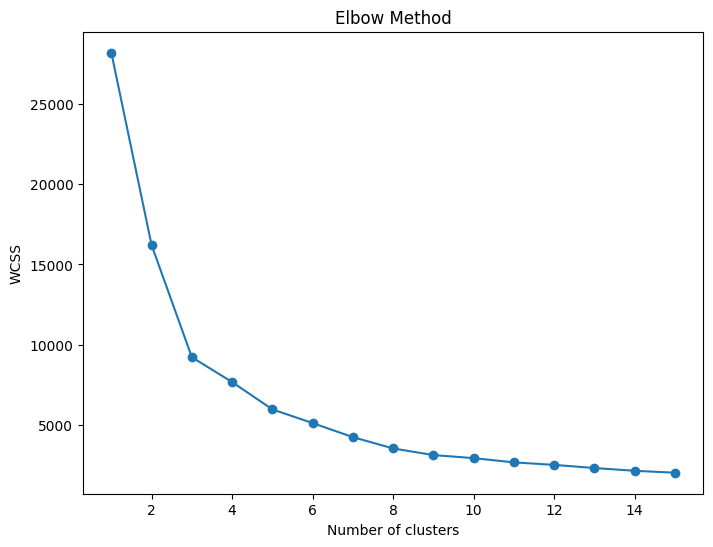

In [718]:
from sklearn.cluster import KMeans
wcss=[]
for k in range (1,16):   #16 is excluded
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show

In [719]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [720]:
segmentation_data['Cluster'] = clusters

In [721]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [722]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [723]:
cluster_name = {
    0:"Budget Loyal customer",
    1:"High risk customer",
    2:"Loyal premium customer"
}

In [724]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_name)

In [725]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,1,High risk customer
1,2,70.70,151.65,0.796013,1,High risk customer
2,8,99.65,820.50,0.805827,1,High risk customer
3,28,104.80,3046.05,0.563031,1,High risk customer
4,49,103.70,5036.30,0.517474,2,Loyal premium customer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0,Budget Loyal customer
7039,24,84.80,1990.50,0.082095,0,Budget Loyal customer
7040,72,103.20,7362.90,0.049001,2,Loyal premium customer
7041,11,29.60,346.45,0.302367,0,Budget Loyal customer


<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

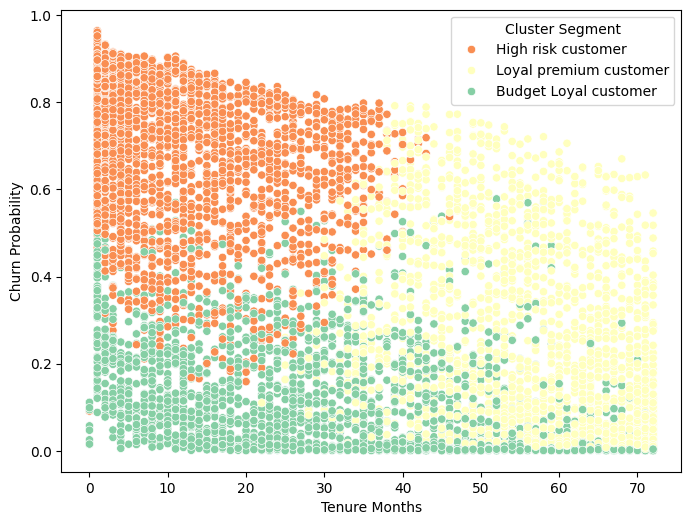

In [726]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data,palette='Spectral')

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

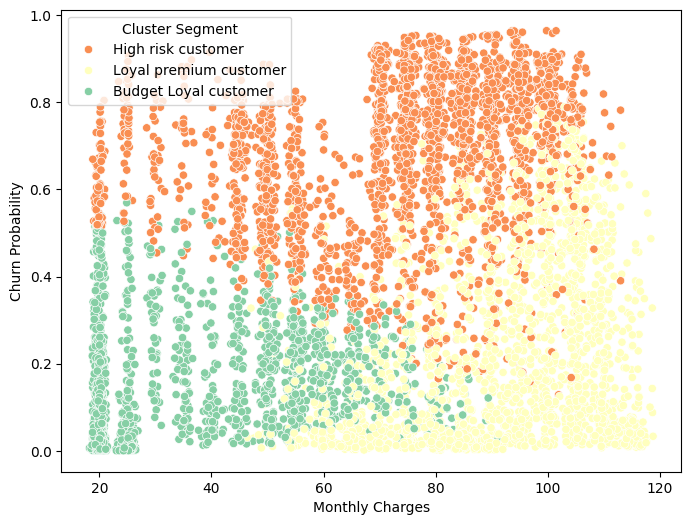

In [727]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data,palette='Spectral')

### Upsell Propensity Analysis: Identifying Customers for Targeted Service Offers

Identifying customers within the 'Budget Loyal customer' and 'Loyal premium customer' segments who are most likely to adopt a new service, even if they currently don't have it. This is crucial for targeted marketing and sales efforts.

We will build a predictive model for one example service (`Streaming TV`) and then use its predictions to segment non-holders into different propensity tiers. This approach allows us to prioritize customers who show higher potential for upsell.

In [728]:
print(X_train[['Monthly Charges', 'Total Charges', 'Tenure Months']].corr())   #drop total charges later

                 Monthly Charges  Total Charges  Tenure Months
Monthly Charges         1.000000       0.655709       0.251454
Total Charges           0.655709       1.000000       0.824467
Tenure Months           0.251454       0.824467       1.000000


In [729]:
df_combined = df_encoded.copy()
df_combined['Cluster Segment'] = segmentation_data['Cluster Segment']

target_segments = ["Budget Loyal customer", "Loyal premium customer"]

In [730]:
segment_pools = {
    seg: df_combined[
        (df_combined['Churn Value'] == 0) & (df_combined['Cluster Segment'] == seg)
    ].copy()
    for seg in target_segments
}

In [731]:
service_cols_to_exclude = [
    'Phone Service_Yes',
    'Multiple Lines_Yes', 'Multiple Lines_No phone service',
    'Internet Service_Fiber optic', 'Internet Service_No',
    'Online Security_Yes', 'Online Security_No internet service',
    'Online Backup_Yes', 'Online Backup_No internet service',
    'Device Protection_Yes', 'Device Protection_No internet service',
    'Tech Support_Yes', 'Tech Support_No internet service',
    'Streaming TV_No internet service', 'Streaming TV_Yes',
    'Streaming Movies_Yes', 'Streaming Movies_No internet service'
]

In [732]:
upsell_services = [
    'Streaming TV_Yes',
    'Streaming Movies_Yes',
    'Online Security_Yes',
    'Online Backup_Yes',
    'Device Protection_Yes',
    'Tech Support_Yes',
    'Multiple Lines_Yes'
]

In [733]:
for seg, pool in segment_pools.items():
    print(f"{seg}: {len(pool)} candidates")

Budget Loyal customer: 2206 candidates
Loyal premium customer: 1853 candidates


In [734]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

In [735]:
loop_results = {}

In [736]:
for seg, pool in segment_pools.items():
    for target_service in upsell_services:
        if target_service not in pool.columns:
            print(f"Skipping {seg} / {target_service} — column not found")
            continue

        Y = pool[target_service]

        # Guard: need both classes present and a minimum sample size to train meaningfully
        if Y.nunique() < 2 or len(pool) < 50:
            print(f"Skipping {seg} / {target_service} — insufficient class variation or sample size ({len(pool)} rows)")
            continue

        current_exclude = [c for c in service_cols_to_exclude if c != target_service]
        no_internet_variant = target_service.replace('_Yes', '_No internet service')
        if no_internet_variant in pool.columns:
            current_exclude.append(no_internet_variant)

        X = pool.drop(
            columns=['Churn Value', 'Cluster Segment', target_service, 'Total Charges'] + current_exclude,
            errors='ignore'
        )

        # Guard: min class count for stratified split (need >=2 per class per split side)
        min_class_count = Y.value_counts().min()
        if min_class_count < 5:
            print(f"Skipping {seg} / {target_service} — minority class too small ({min_class_count}) to stratify reliably")
            continue

        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, test_size=0.2, random_state=42, stratify=Y
        )

        dummy = DummyClassifier(strategy='most_frequent', random_state=42)
        dummy.fit(X_train, Y_train)
        dummy_auc = roc_auc_score(Y_test, dummy.predict_proba(X_test)[:, 1])

        rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=10)
        rf.fit(X_train, Y_train)

        Y_prob = rf.predict_proba(X_test)[:, 1]
        model_auc = roc_auc_score(Y_test, Y_prob)
        cv_scores = cross_val_score(rf, X, Y, cv=5, scoring='roc_auc')

        loop_results[(seg, target_service)] = {
            'model': rf,
            'X_columns': X_train.columns.tolist(),
            'current_exclude': current_exclude,
            'pool_size': len(pool),
            'class_dist': Y.mean(),
            'dummy_auc': dummy_auc,
            'model_auc': model_auc,
            'lift': model_auc - dummy_auc,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'top_feature': pd.Series(rf.feature_importances_, index=X_train.columns).idxmax()
        }

        print(f"✓ {seg[:20]:<20} | {target_service:<25} | AUC: {model_auc:.4f} | Lift: {model_auc - dummy_auc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


✓ Budget Loyal custome | Streaming TV_Yes          | AUC: 0.9147 | Lift: 0.4147 | CV: 0.9147 ± 0.0105
✓ Budget Loyal custome | Streaming Movies_Yes      | AUC: 0.9091 | Lift: 0.4091 | CV: 0.9137 ± 0.0043
✓ Budget Loyal custome | Online Security_Yes       | AUC: 0.9345 | Lift: 0.4345 | CV: 0.9186 ± 0.0138
✓ Budget Loyal custome | Online Backup_Yes         | AUC: 0.8927 | Lift: 0.3927 | CV: 0.8904 ± 0.0108
✓ Budget Loyal custome | Device Protection_Yes     | AUC: 0.8806 | Lift: 0.3806 | CV: 0.8857 ± 0.0121
✓ Budget Loyal custome | Tech Support_Yes          | AUC: 0.9115 | Lift: 0.4115 | CV: 0.9100 ± 0.0103
✓ Budget Loyal custome | Multiple Lines_Yes        | AUC: 0.9505 | Lift: 0.4505 | CV: 0.9556 ± 0.0074
✓ Loyal premium custom | Streaming TV_Yes          | AUC: 0.7914 | Lift: 0.2914 | CV: 0.8089 ± 0.0142
✓ Loyal premium custom | Streaming Movies_Yes      | AUC: 0.7909 | Lift: 0.2909 | CV: 0.8080 ± 0.0168
✓ Loyal premium custom | Online Security_Yes       | AUC: 0.6862 | Lift: 0.1862 | 

In [737]:
summary_df = pd.DataFrame(loop_results).T.drop(columns=['model', 'X_columns', 'current_exclude'])
summary_df.index = pd.MultiIndex.from_tuples(summary_df.index, names=['Segment', 'Service'])
summary_df = summary_df.astype({
    'pool_size': float, 'class_dist': float, 'dummy_auc': float, 'model_auc': float,
    'lift': float, 'cv_mean': float, 'cv_std': float
}).round(4)

# AUC unreliable: tiny minority class or high CV instability
summary_df['Positive_Count'] = (summary_df['pool_size'] * summary_df['class_dist']).round(0).astype(int)
summary_df['Reliability_Flag'] = np.where(
    (summary_df['Positive_Count'] < 30) | (summary_df['cv_std'] > 0.02),
    '⚠ Low confidence',
    'OK'
)

In [738]:
# WHY flagged
flagged = summary_df[summary_df['Reliability_Flag'] == '⚠ Low confidence']
flagged['Flag_Reason'] = np.where(
    flagged['Positive_Count'] < 30, 'Low positive count',
    np.where(flagged['cv_std'] > 0.02, 'High CV instability', 'Unknown')
)
display(flagged[['pool_size', 'Positive_Count', 'cv_mean', 'cv_std', 'Flag_Reason']])

/tmp/ipykernel_7806/1830715668.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flagged['Flag_Reason'] = np.where(


pool_size  Positive_Count  \
Segment                Service                                            
Loyal premium customer Online Security_Yes       1853.0            1073   
                       Online Backup_Yes         1853.0            1265   
                       Device Protection_Yes     1853.0            1287   
                       Tech Support_Yes          1853.0            1106   

                                              cv_mean  cv_std  \
Segment                Service                                  
Loyal premium customer Online Security_Yes     0.7048  0.0255   
                       Online Backup_Yes       0.6466  0.0223   
                       Device Protection_Yes   0.6764  0.0233   
                       Tech Support_Yes        0.7573  0.0226   

                                                      Flag_Reason  
Segment                Service                                     
Loyal premium customer Online Security_Yes    High CV instability  
                       Online Backup_Yes      High CV instability  
                       Device Protection_Yes  High CV instability  
                       Tech Support_Yes       High CV instability

In [739]:
# Check unstable Premium models share common top features as root cause, not unrelated

unstable_services = ['Multiple Lines_Yes', 'Online Security_Yes', 'Online Backup_Yes', 'Device Protection_Yes']
target_segment = 'Loyal premium customer'

In [740]:
top5_sets = {}
for svc in unstable_services:
    key = (target_segment, svc)
    if key not in loop_results:
        continue
    res = loop_results[key]
    importances = pd.Series(res['model'].feature_importances_, index=res['X_columns'])
    top5_sets[svc] = set(importances.sort_values(ascending=False).head(5).index)


In [741]:
common_all = set.intersection(*top5_sets.values())
print(f"\nFeature(s) in top-5 of ALL unstable models: {common_all if common_all else 'none'}")



Feature(s) in top-5 of ALL unstable models: {'Paperless Billing_Yes', 'Tenure Months', 'Monthly Charges', 'Gender_Male'}


feature_importances_ for these Premium models all converge on the same top features, i.e the instability may have a common cause

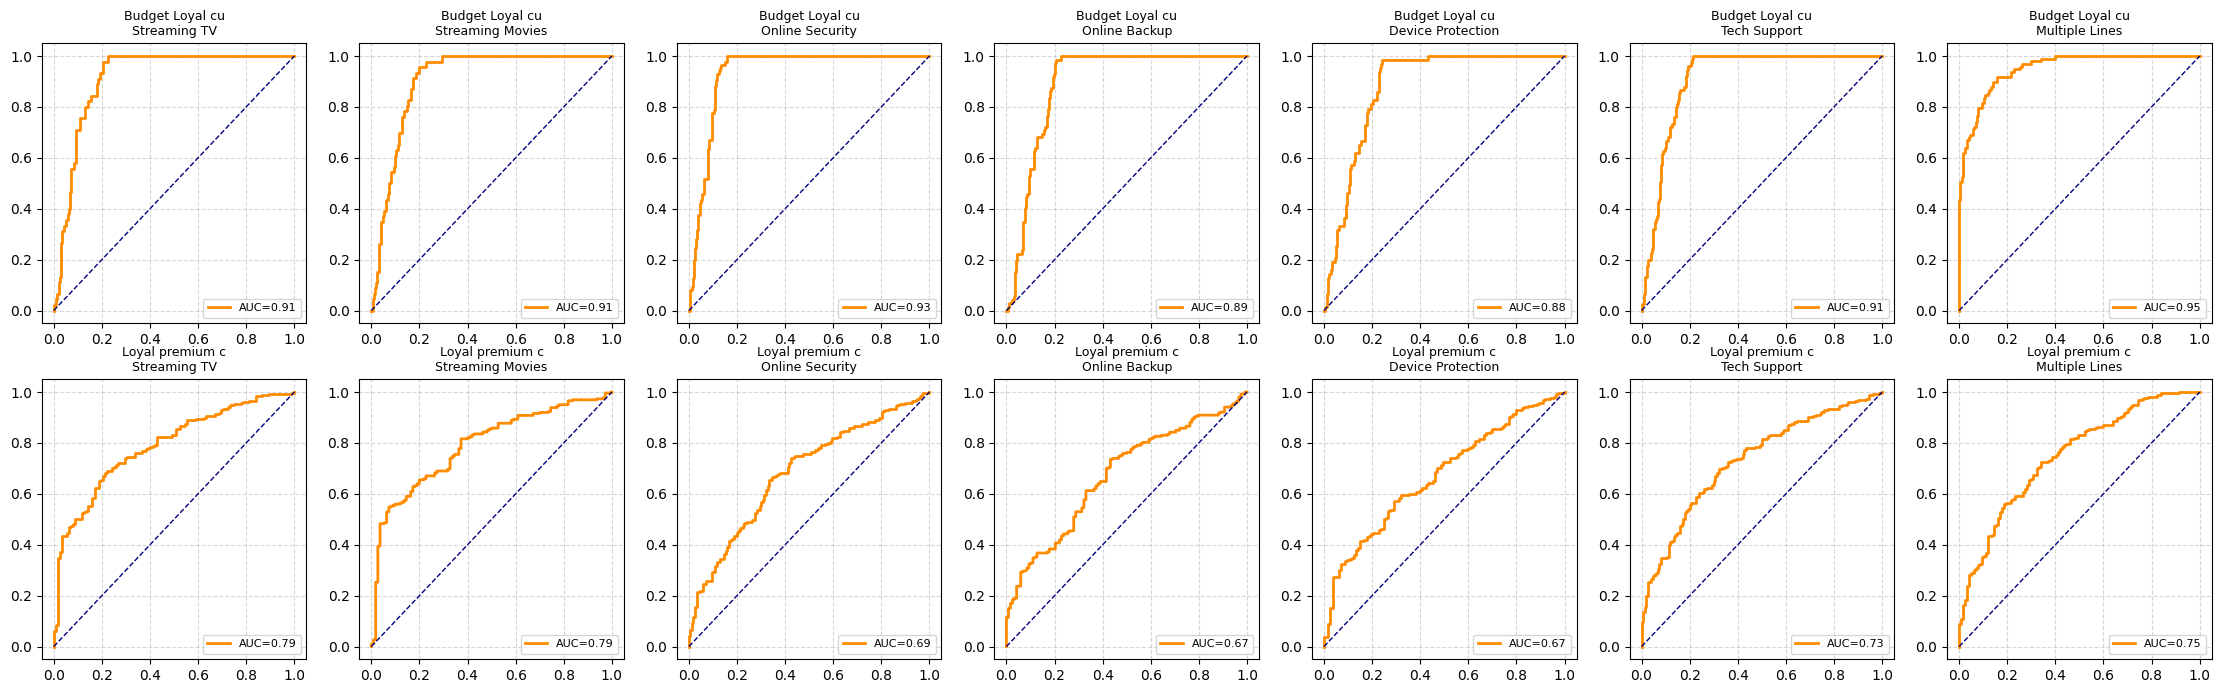

In [742]:
n_segs = len(segment_pools)
n_svc = len(upsell_services)
fig, axes = plt.subplots(n_segs, n_svc, figsize=(4 * n_svc, 4 * n_segs))
if n_segs == 1:
    axes = axes.reshape(1, -1)

for r, seg in enumerate(segment_pools.keys()):
    for c, target_service in enumerate(upsell_services):
        ax = axes[r, c]
        key = (seg, target_service)
        if key not in loop_results:
            ax.set_visible(False)
            continue

        res = loop_results[key]
        pool = segment_pools[seg]
        current_exclude = res['current_exclude']

        Y = pool[target_service]
        X = pool.drop(
            columns=['Churn Value', 'Cluster Segment', target_service, 'Total Charges'] + current_exclude,
            errors='ignore'
        )

        _, X_test, _, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
        Y_prob = res['model'].predict_proba(X_test[res['X_columns']])[:, 1]

        fpr, tpr, _ = roc_curve(Y_test, Y_prob)
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC={res['model_auc']:.2f}")
        ax.plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--')
        ax.set_title(f"{seg[:15]}\n{target_service.replace('_Yes','')}", fontsize=9)
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.5)

In [743]:
plt.suptitle('ROC Curves: Upsell Propensity Models by Segment × Service', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [744]:
propensity_store = {}

In [745]:
for seg, pool in segment_pools.items():
    for target_service in upsell_services:
        key = (seg, target_service)
        if key not in loop_results:
            continue

        res = loop_results[key]
        current_exclude = res['current_exclude']

        non_holders = pool[pool[target_service] == 0].copy()

        X_non_holders = non_holders.drop(
            columns=['Churn Value', 'Cluster Segment', target_service, 'Total Charges'] + current_exclude,
            errors='ignore'
        )[res['X_columns']]

        if X_non_holders.empty:
            continue

        non_holders['Upsell_Propensity_Score'] = res['model'].predict_proba(X_non_holders)[:, 1]
        non_holders['Propensity_Tier'] = pd.cut(
            non_holders['Upsell_Propensity_Score'],
            bins=[0, 0.33, 0.66, 1.0],
            labels=['Low Opportunity', 'Medium Opportunity', 'High Opportunity'],
            include_lowest=True
        )

        propensity_store[key] = non_holders

In [746]:
opportunity_rows = []


In [747]:
for (seg, target_service), non_holders in propensity_store.items():
    high_tier = non_holders[non_holders['Propensity_Tier'] == 'High Opportunity']
    n = len(non_holders)

    opportunity_rows.append({
        'Segment': seg,
        'Service': target_service.replace('_Yes', ''),
        'Total_Non_Holders': n,
        'Num_High_Opportunity': len(high_tier),
        'High_Opportunity_Pct': len(high_tier)/n if n else 0,
        'Avg_Propensity_Score':
            non_holders['Upsell_Propensity_Score'].mean(),
        'Model_AUC':
            loop_results[(seg,target_service)]['model_auc']
    })

In [748]:
opportunity_df = pd.DataFrame(opportunity_rows).round(3)

In [749]:
opportunity_df['Rank_Within_Segment'] = (opportunity_df.groupby('Segment')['Avg_Propensity_Score'].rank(ascending=False, method='dense').astype(int))

In [750]:
ranked_df = opportunity_df.sort_values(['Segment', 'Rank_Within_Segment'])

In [751]:
print("=== Best Upsell Services WITHIN Each Segment ===")

display(ranked_df[['Segment','Rank_Within_Segment','Service','Avg_Propensity_Score','High_Opportunity_Pct','Num_High_Opportunity','Total_Non_Holders']])

=== Best Upsell Services WITHIN Each Segment ===


,Segment,Rank_Within_Segment,Service,Avg_Propensity_Score,High_Opportunity_Pct,Num_High_Opportunity,Total_Non_Holders
3,Budget Loyal customer,1,Online Backup,0.110,0.016,30,1849
4,Budget Loyal customer,1,Device Protection,0.110,0.011,20,1890
5,Budget Loyal customer,2,Tech Support,0.107,0.019,34,1831
6,Budget Loyal customer,3,Multiple Lines,0.106,0.003,5,1721
2,Budget Loyal customer,4,Online Security,0.104,0.026,46,1782
0,Budget Loyal customer,5,Streaming TV,0.081,0.009,17,1980
1,Budget Loyal customer,6,Streaming Movies,0.080,0.009,18,1977
10,Loyal premium customer,1,Online Backup,0.384,0.058,34,588
11,Loyal premium customer,2,Device Protection,0.365,0.055,31,566
13,Loyal premium customer,3,Multiple Lines,0.335,0.039,23,585


/tmp/ipykernel_7806/3311513842.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_sorted,x='Avg_Propensity_Score',y='Service',ax=ax,palette='viridis')
/tmp/ipykernel_7806/3311513842.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_sorted,x='Avg_Propensity_Score',y='Service',ax=ax,palette='viridis')


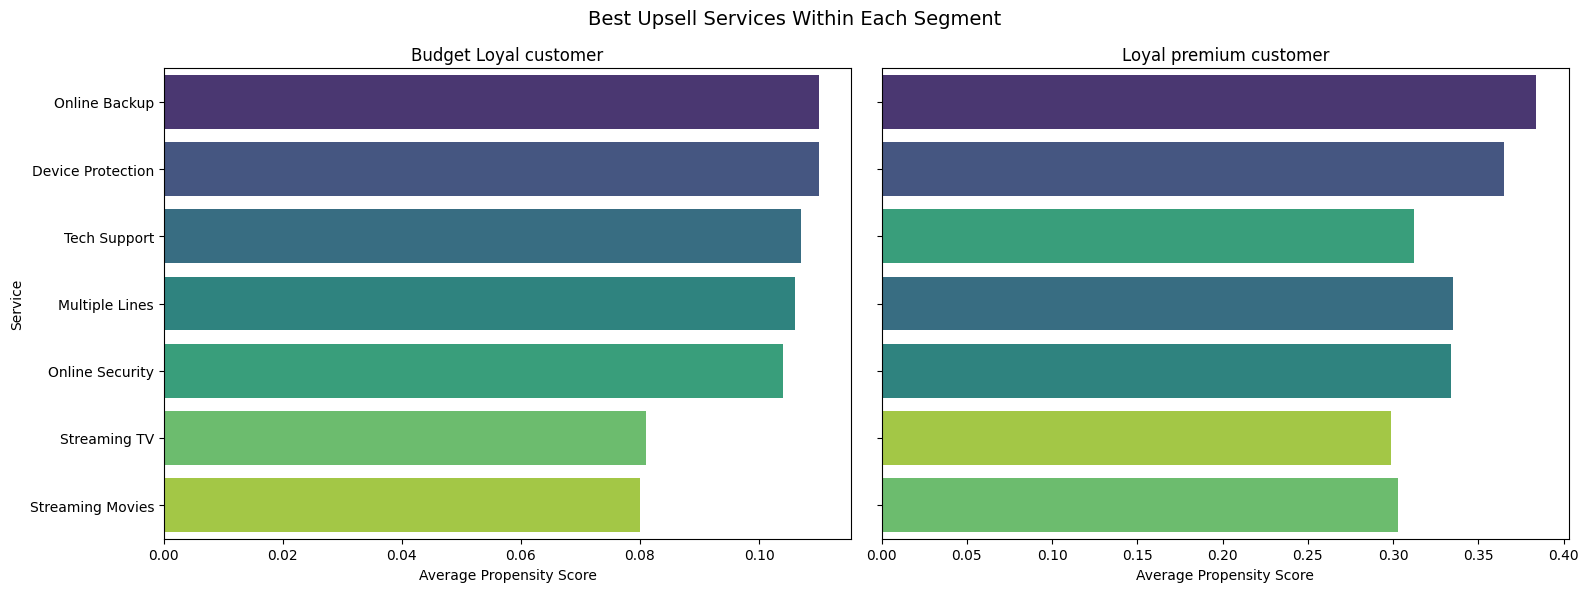

In [752]:
fig, axes = plt.subplots(1,2,figsize=(16,6),sharey=True)


for ax,(seg,sub) in zip(axes, opportunity_df.groupby('Segment')):

    sub_sorted=sub.sort_values('Avg_Propensity_Score',ascending=False)

    sns.barplot(data=sub_sorted,x='Avg_Propensity_Score',y='Service',ax=ax,palette='viridis')

    ax.set_title(seg)

    ax.set_xlabel('Average Propensity Score')

plt.suptitle('Best Upsell Services Within Each Segment',fontsize=14)
plt.tight_layout()
plt.show()

Testing whether Premium instability is model-specific

In [753]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr_results=[]

In [754]:

for seg,pool in segment_pools.items():
    for target_service in upsell_services:
        key=(seg,target_service)
        if key not in loop_results:
            continue
        current_exclude=loop_results[key]['current_exclude']

        Y=pool[target_service]
        X=pool.drop(columns=['Churn Value','Cluster Segment',target_service,'Total Charges'] +current_exclude, errors='ignore')

        X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.2,random_state=42,stratify=Y)

        lr=LogisticRegression(class_weight='balanced', max_iter=2000)

        lr.fit(X_train,Y_train)

        pred=lr.predict_proba(X_test)[:,1]

        auc=roc_auc_score(Y_test, pred)

        cv=cross_val_score(lr,X,Y,cv=5,scoring='roc_auc')

        lr_results.append({'Segment':seg,'Service':target_service, 'LR_AUC':auc, 'LR_CV':cv.mean()})



In [755]:
lr_df=pd.DataFrame(lr_results)

In [756]:
rf_df=summary_df.reset_index()[
    ['Segment',
     'Service',
     'model_auc',
     'cv_mean']
]

compare=rf_df.merge(lr_df, on=['Segment','Service'])

compare=compare.rename(columns={'model_auc':'RF_AUC','cv_mean':'RF_CV'})

display(compare)

,Segment,Service,RF_AUC,RF_CV,LR_AUC,LR_CV
0,Budget Loyal customer,Streaming TV_Yes,0.9147,0.9147,0.916429,0.911979
1,Budget Loyal customer,Streaming Movies_Yes,0.9091,0.9137,0.910903,0.920215
2,Budget Loyal customer,Online Security_Yes,0.9345,0.9186,0.934915,0.909051
3,Budget Loyal customer,Online Backup_Yes,0.8927,0.8904,0.910435,0.899218
4,Budget Loyal customer,Device Protection_Yes,0.8806,0.8857,0.880555,0.889451
5,Budget Loyal customer,Tech Support_Yes,0.9115,0.9100,0.893333,0.899123
6,Budget Loyal customer,Multiple Lines_Yes,0.9505,0.9556,0.671806,0.705897
7,Loyal premium customer,Streaming TV_Yes,0.7914,0.8089,0.771029,0.790717
8,Loyal premium customer,Streaming Movies_Yes,0.7909,0.8080,0.762208,0.786000
9,Loyal premium customer,Online Security_Yes,0.6862,0.7048,0.677221,0.698300


In [757]:
# Bootstrap 95% CI for AUC of every trained model

bootstrap_results = []

n_boot = 500

for (segment, service), res in loop_results.items():

    pool = segment_pools[segment]
    current_exclude = res['current_exclude']

    Y = pool[service]

    X = pool.drop(columns=['Churn Value','Cluster Segment',service,'Total Charges'] + current_exclude,errors='ignore')

    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

    prob = res['model'].predict_proba(X_test[res['X_columns']])[:, 1]

    boot = []

    for _ in range(n_boot):
        idx = np.random.choice(len(Y_test),size=len(Y_test),replace=True)
        auc = roc_auc_score(Y_test.iloc[idx],prob[idx])
        boot.append(auc)

    low = np.percentile(boot, 2.5)
    high = np.percentile(boot, 97.5)

    bootstrap_results.append({'Segment': segment,'Service': service,'AUC': res['model_auc'],'CI_Lower': low,'CI_Upper': high,'CI_Width': high - low})

bootstrap_df = pd.DataFrame(bootstrap_results).round(4)

display(
    bootstrap_df.sort_values(['Segment', 'AUC'],ascending=[True, False])
)

,Segment,Service,AUC,CI_Lower,CI_Upper,CI_Width
6,Budget Loyal customer,Multiple Lines_Yes,0.9505,0.9314,0.9696,0.0382
2,Budget Loyal customer,Online Security_Yes,0.9345,0.9122,0.9551,0.0429
0,Budget Loyal customer,Streaming TV_Yes,0.9147,0.8863,0.9399,0.0536
5,Budget Loyal customer,Tech Support_Yes,0.9115,0.8838,0.9370,0.0533
1,Budget Loyal customer,Streaming Movies_Yes,0.9091,0.8782,0.9359,0.0577
3,Budget Loyal customer,Online Backup_Yes,0.8927,0.8661,0.9220,0.0559
4,Budget Loyal customer,Device Protection_Yes,0.8806,0.8446,0.9121,0.0675
7,Loyal premium customer,Streaming TV_Yes,0.7914,0.7457,0.8381,0.0925
8,Loyal premium customer,Streaming Movies_Yes,0.7909,0.7432,0.8386,0.0954
13,Loyal premium customer,Multiple Lines_Yes,0.7501,0.6933,0.8005,0.1072


Bootstrap resampling confirmed that lower Premium AUCs persisted beyond sampling variability

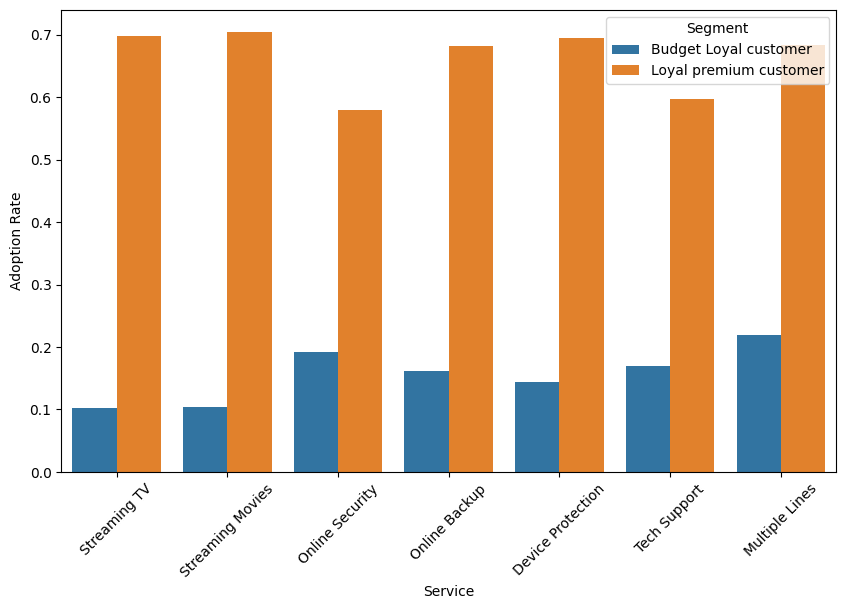

In [758]:
sat=[]

for seg,pool in segment_pools.items():
    for service in upsell_services:
        sat.append({
            'Segment':seg,
            'Service':service.replace('_Yes',''),
            'Adoption':pool[service].mean()
        })

sat=pd.DataFrame(sat)

plt.figure(figsize=(10,6))
sns.barplot(data=sat,x='Service',y='Adoption',hue='Segment')
plt.xticks(rotation=45)
plt.ylabel("Adoption Rate")
plt.show()

Premium customers are largely saturated hence not enough strong features to predict people that can adopt certain add on services

